Matplotlib is building the font cache; this may take a moment.


Training the ML model... please wait...
Model Training Complete! Accuracy: 100.00%


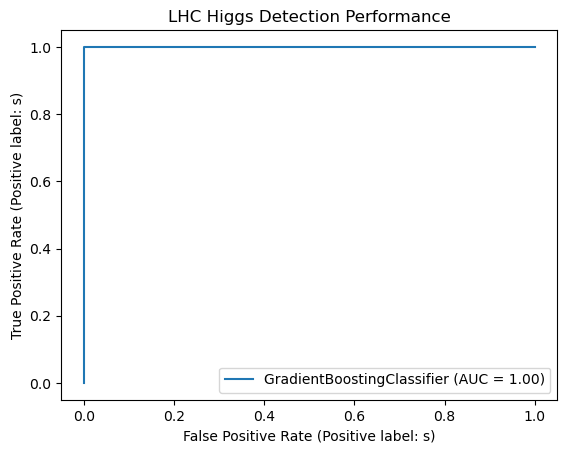

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import RocCurveDisplay

# 1. Load data (Make sure this filename matches your unzipped file precisely)
df = pd.read_csv("atlas-higgs-challenge-2014-v2.csv")

# Clean the dataset for training
# We drop metadata columns and separate features from the target label
X = df.drop(columns=["EventId", "Label", "KaggleSet", "KaggleWeight"])  
y = df["Label"]  # 's' for signal (Higgs), 'b' for background

# 2. Split into Train (80%) and Test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Model (This might take 1–2 minutes to process)
print("Training the ML model... please wait...")
model = GradientBoostingClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# 4. Print Results
accuracy = model.score(X_test, y_test)
print(f"Model Training Complete! Accuracy: {accuracy * 100:.2f}%")

# 5. Plot the ROC Curve (Performance Graph)
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("LHC Higgs Detection Performance")
plt.show()
